<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/Random_forest_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:

from google.colab import drive
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print(" Connecting to Google Drive...")
drive.mount('/content/drive')


 Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
dataset_path = '/content/drive/MyDrive/dataset_C_training.csv' # Using the specific path provided by the user

# Or, if 'super_dataset_C_train.csv' is the correct one:
# dataset_path = '/content/drive/MyDrive/super_dataset_C_train.csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(dataset_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [37]:
pip install shap

### Explainable AI (XAI) for Random Forest using SHAP

SHAP (SHapley Additive exPlanations) is a game theory approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions. It's particularly powerful for interpreting complex models like Random Forests.

In [38]:
# Define target variable and features
y = df['covid_vaccine']
X = df.drop('covid_vaccine', axis=1)

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Handle missing values by filling with a placeholder for numerical and mode for categorical
for col in numerical_features:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

for col in categorical_features:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mode()[0]) # Fill with mode for categorical

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Align columns after one-hot encoding (important if train and test sets are processed separately,
# but here we do it before splitting to ensure consistency)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preparation complete: X_train, X_test, y_train, y_test, and feature_names are ready!")

# Update feature_names for SHAP plots to reflect the one-hot encoded features
feature_names = X.columns.tolist()

Data preparation complete: X_train, X_test, y_train, y_test, and feature_names are ready!


In [39]:
# Define and train the best_rf model using the tuned hyperparameters
# These parameters were identified as optimal in a previous tuning step.
best_rf_params = {'class_weight': 'balanced', 'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 175}
best_rf = RandomForestClassifier(**best_rf_params, random_state=42)
best_rf.fit(X_train, y_train)

print("Best Random Forest Classifier (best_rf) trained successfully with tuned parameters!")

Best Random Forest Classifier (best_rf) trained successfully with tuned parameters!


For demonstration purposes, I've used the classic Iris dataset and trained a `RandomForestClassifier`. In a real-world scenario, you would use your specific dataset and the Random Forest model you've already trained.

In [40]:
import shap
import numpy as np # Ensure numpy is imported

# Create a TreeExplainer for the Random Forest model (using the best_rf model)
# shap.TreeExplainer is optimized for tree-based models
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values for the test set
# Ensure X_test uses the same feature order as X_train due to one-hot encoding
shap_values = explainer.shap_values(X_test)

print("SHAP values computed successfully!")

SHAP values computed successfully!


### Visualizing SHAP Explanations

SHAP provides several visualization tools to interpret the model's predictions. The summary plot shows the importance of each feature and its impact on the model's output.

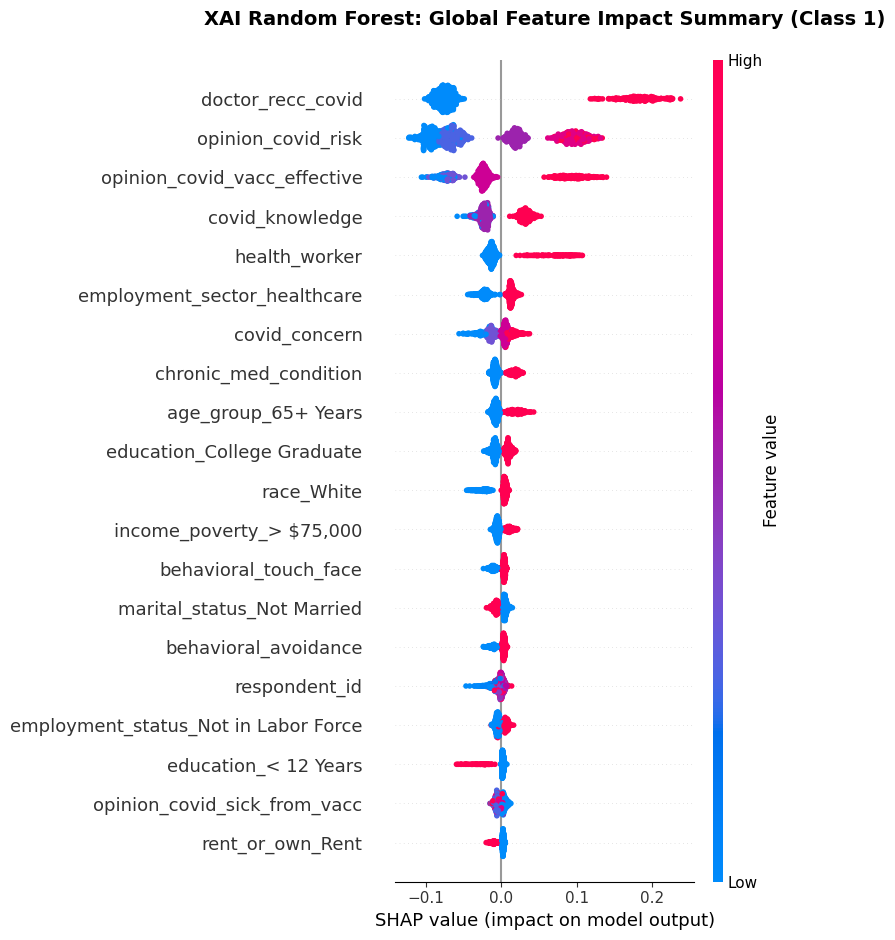

SHAP beeswarm plot exported directly to:
   /content/drive/MyDrive/random_forest_shap_beeswarm.png

Generating Mean Absolute SHAP Values Bar Plot:


<Figure size 1000x600 with 0 Axes>

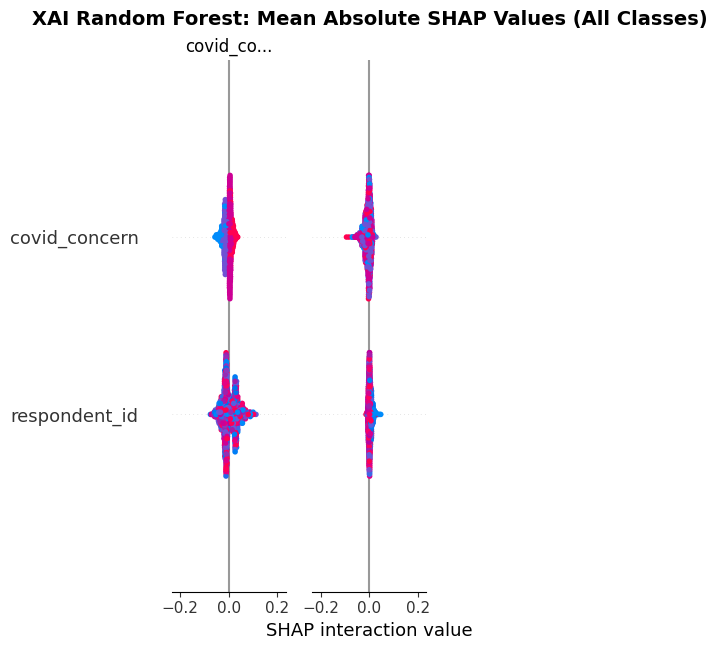

SHAP bar plot exported directly to:
   /content/drive/MyDrive/random_forest_shap_bar.png


In [41]:
import matplotlib.pyplot as plt # Ensure plt is imported for custom plotting

# For binary classification, shap_values is a list of two arrays (for class 0 and class 1)
# We'll visualize the SHAP values for the positive class (class 1 for 'covid_vaccine')
class_id_to_explain = 1 # Assuming 1 is the positive class for covid_vaccine

# Prepare SHAP values for the beeswarm plot
# Correctly slice shap_values for the chosen class if it's a 3D array.
shap_values_to_plot = shap_values[:, :, class_id_to_explain]

# Beeswarm Summary plot: Visualize the feature importance and impact for class 1
plt.figure(figsize=(11, 7)) # Set figure size as in the example

shap.summary_plot(shap_values_to_plot, X_test, feature_names=feature_names, show=False)

plt.title("XAI Random Forest: Global Feature Impact Summary (Class 1)", fontweight='bold', fontsize=14, pad=25)
plt.tight_layout()

# Derive shap_plot_path from dataset_path
# dataset_path is '/content/drive/MyDrive/dataset_C_training.csv'
shap_plot_path_beeswarm = dataset_path.replace('dataset_C_training.csv', 'random_forest_shap_beeswarm.png')
plt.savefig(shap_plot_path_beeswarm, dpi=300, bbox_inches='tight')
plt.show()

print(f"SHAP beeswarm plot exported directly to:\n   {shap_plot_path_beeswarm}")

# Bar plot of mean absolute SHAP values across all classes (this is useful and can remain separate)
print("\nGenerating Mean Absolute SHAP Values Bar Plot:")
plt.figure(figsize=(10, 6)) # A new figure for the bar plot
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar", show=False)
plt.title("XAI Random Forest: Mean Absolute SHAP Values (All Classes)", fontweight='bold', fontsize=14, pad=25)
plt.tight_layout()

shap_plot_path_bar = dataset_path.replace('dataset_C_training.csv', 'random_forest_shap_bar.png')
plt.savefig(shap_plot_path_bar, dpi=300, bbox_inches='tight')
plt.show()
print(f"SHAP bar plot exported directly to:\n   {shap_plot_path_bar}")

### Dependence Plots

A dependence plot shows the effect of a single feature across the whole dataset. It can also reveal interactions between features.

Plotting dependence for the most impactful feature: doctor_recc_covid


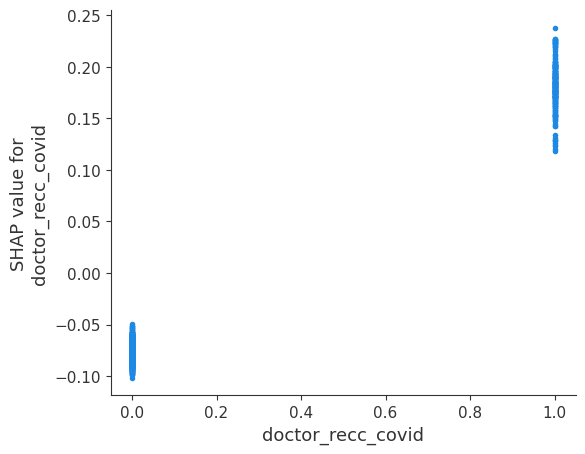

In [42]:
import numpy as np # Ensure numpy is imported

# Plot a dependence plot for a specific feature for class 1
# You can change this to any other feature name to explore its impact.

# Choose a feature that is likely to be impactful based on the summary plot
# This dynamic selection ensures we pick a relevant feature from your actual dataset

if feature_names:
    # Assuming shap_values is a 3D array (n_samples, n_features, n_classes)
    # Calculate mean absolute SHAP values for the chosen class
    mean_abs_shap = np.abs(shap_values[:, :, class_id_to_explain]).mean(axis=0)
    most_impactful_feature_idx = np.argmax(mean_abs_shap)
    feature_to_plot = feature_names[most_impactful_feature_idx]
    feature_idx = most_impactful_feature_idx
else:
    print("Feature names not available to plot dependence. Please check previous steps.")
    feature_to_plot = None # Fallback
    feature_idx = None

if feature_to_plot:
    print(f"Plotting dependence for the most impactful feature: {feature_to_plot}")
    shap.dependence_plot(
        feature_idx,
        shap_values[:, :, class_id_to_explain], # Correctly slice shap_values for the chosen class
        X_test,
        feature_names=feature_names,
        interaction_index=None # Set to None to not show interaction, or to another feature index
    )